In [15]:
import numpy as np
from matplotlib import pyplot as plt

from scipy.integrate import solve_ivp

m=1.67262192369*(10**-27)
q=1.602176634*(10**-19)



def lorentz(t,y):
    x, y_pos, vx, vy = y
    r = np.sqrt(x ** 2 + y_pos ** 2)

    if r<0.04 :
        B = np.array([0, 0, 3])
        w = (q / m) * float(np.linalg.norm(B))
    else:
        B = np.array([0, 0, 0])
        w = (q / m) * float(np.linalg.norm(B))


    if -0.001<x<0.001 and -0.04<y_pos<0.04:
        E = np.array([((10**6) * np.sign(np.sin(t * w))), 0, 0])
    else:
        E=np.array([0,0,0])

    v=np.array([vx,vy,0])
    a=(q/m)*(E+np.cross(v,B))

    return [vx,vy,a[0],a[1]]
print("Your simulation is running")
y0=[0,0,0,0]

t_sp=(0,10**-6)
t_eval=np.linspace(t_sp[0],t_sp[1],20000)

sol1=solve_ivp(lorentz,t_sp,y0,t_eval=t_eval,max_step=(10**-10))

Your simulation is running


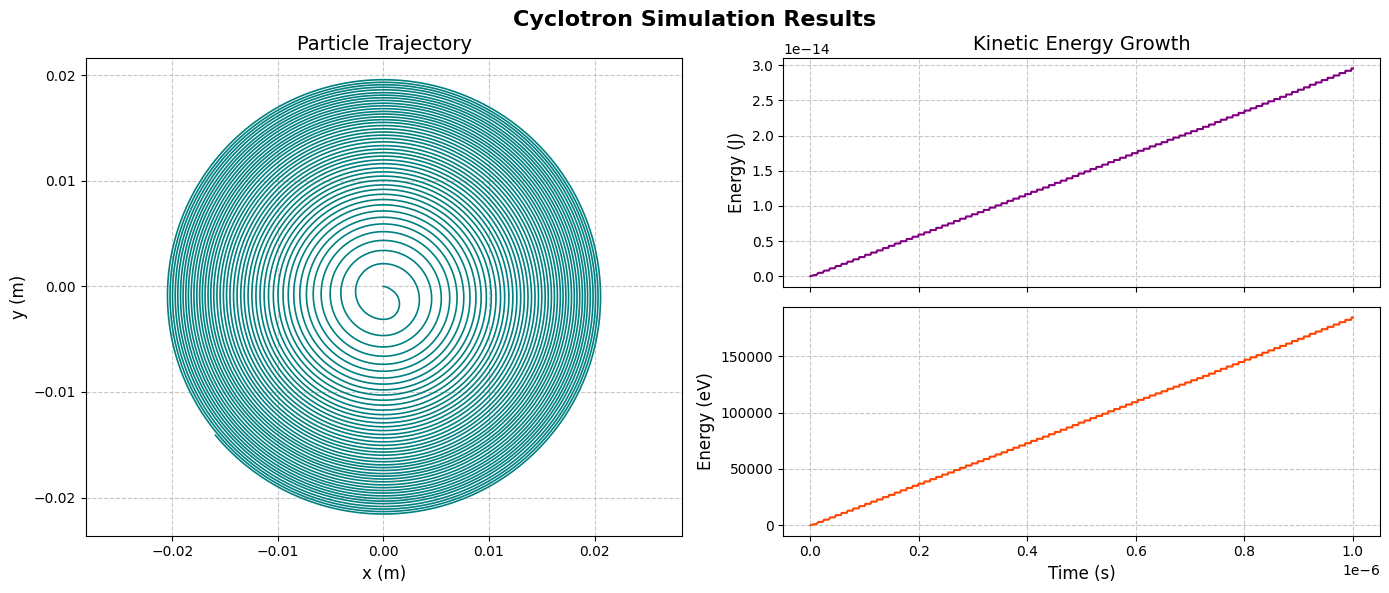

In [16]:
# --- Energy Calculations ---
k_joules = 0.5 * m * ((sol1.y[2]**2) + (sol1.y[3]**2))
k_eV = k_joules / q

# --- Aesthetically Arranged Plotting Dashboard ---
fig = plt.figure(figsize=(14, 6))
fig.suptitle('Cyclotron Simulation Results', fontsize=16, fontweight='bold')

# 1. Trajectory Plot (Left side)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(sol1.y[0], sol1.y[1], linewidth=1.2, color='teal')
ax1.set_xlabel('x (m)', fontsize=12)
ax1.set_ylabel('y (m)', fontsize=12)
ax1.set_title('Particle Trajectory', fontsize=14)
ax1.axis('equal')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Kinetic Energy in Joules (Top Right)
ax2 = plt.subplot(2, 2, 2)
ax2.plot(t_eval, k_joules, color='purple', linewidth=1.5)
ax2.set_ylabel('Energy (J)', fontsize=12)
ax2.set_title('Kinetic Energy Growth', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(labelbottom=False) # Hide x-axis labels to keep it clean

# 3. Kinetic Energy in eV (Bottom Right)
ax3 = plt.subplot(2, 2, 4, sharex=ax2)
ax3.plot(t_eval, k_eV, color='orangered', linewidth=1.5)
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel('Energy (eV)', fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.7)

# Final layout adjustments
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()